#Data-Driven Social Engagement Analytics System

To analyze social media engagement data, understand audience sentiment, identify viral content, and predict engagement using machine learning.

In [2]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#load dataset
df = pd.read_csv("Social_media_Dataset.csv")

In [5]:
df.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,NaN,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",NaN,...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport",...,743,6696,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName",...,703,47315,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8


##Module 1: Data Cleaning

In [6]:
df.shape #check shape

(12000, 28)

In [7]:
df.columns #check column

Index(['post_id', 'timestamp', 'day_of_week', 'platform', 'user_id',
       'location', 'language', 'text_content', 'hashtags', 'mentions',
       'keywords', 'topic_category', 'sentiment_score', 'sentiment_label',
       'emotion_type', 'toxicity_score', 'likes_count', 'shares_count',
       'comments_count', 'impressions', 'engagement_rate', 'brand_name',
       'product_name', 'campaign_name', 'campaign_phase',
       'user_past_sentiment_avg', 'user_engagement_growth',
       'buzz_change_rate'],
      dtype='object')

In [8]:
df.info() #check infomation


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   post_id                  12000 non-null  object 
 1   timestamp                12000 non-null  object 
 2   day_of_week              12000 non-null  object 
 3   platform                 12000 non-null  object 
 4   user_id                  12000 non-null  object 
 5   location                 12000 non-null  object 
 6   language                 12000 non-null  object 
 7   text_content             12000 non-null  object 
 8   hashtags                 12000 non-null  object 
 9   mentions                 8059 non-null   object 
 10  keywords                 12000 non-null  object 
 11  topic_category           12000 non-null  object 
 12  sentiment_score          12000 non-null  float64
 13  sentiment_label          12000 non-null  object 
 14  emotion_type          

In [9]:
df.isnull().sum() #Missing values

,0
post_id,0
timestamp,0
day_of_week,0
platform,0
user_id,0
location,0
language,0
text_content,0
hashtags,0
mentions,3941


In [10]:
df.drop_duplicates(inplace=True) #remove duplicate


##Module 2: Exploratory Data Analysis (EDA)

In [11]:
df.describe() #Statistical Summary

,sentiment_score,toxicity_score,likes_count,shares_count,comments_count,impressions,engagement_rate,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
count,12000.000000,12000.000000,12000.00000,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,0.000553,0.503868,2490.72025,1007.167167,504.34575,49811.338500,0.278137,0.001472,0.000998,0.729692
std,0.583563,0.288198,1441.53253,575.072282,288.68416,28930.289451,1.149206,0.576627,0.289940,57.787219
min,-0.999800,0.000000,0.00000,0.000000,0.00000,130.000000,0.001880,-0.999600,-0.499900,-99.900000
25%,-0.503200,0.251400,1236.00000,510.000000,253.00000,24716.500000,0.049100,-0.495975,-0.248400,-48.700000
50%,-0.006200,0.505950,2496.00000,1018.000000,503.00000,49674.000000,0.080605,0.001950,0.002800,0.900000
75%,0.513525,0.756200,3723.25000,1501.000000,755.00000,74815.000000,0.163123,0.501725,0.250700,50.100000
max,0.999900,0.999900,5000.00000,2000.000000,1000.00000,99997.000000,32.211710,0.999400,0.499900,99.900000


purpose: Understand overall dataset characteristics.

In [12]:
#Platform Distribution
df["platform"].value_counts()

,count
platform,
YouTube,2436
Facebook,2431
Twitter,2406
Reddit,2372
Instagram,2355


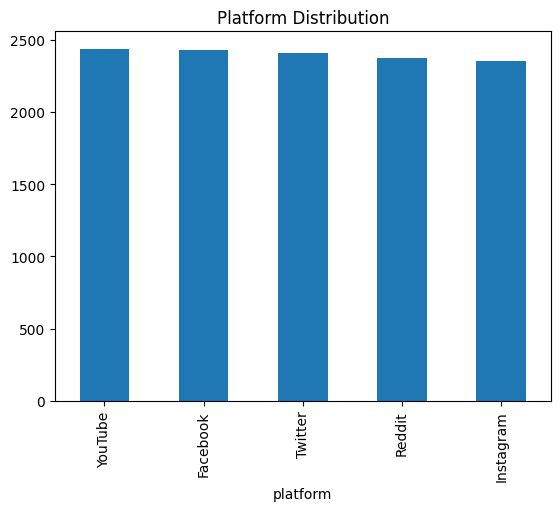

In [13]:
#graph
df["platform"].value_counts().plot(kind="bar")
plt.title("Platform Distribution")
plt.show()

##Module 3: Sentiment Analysis

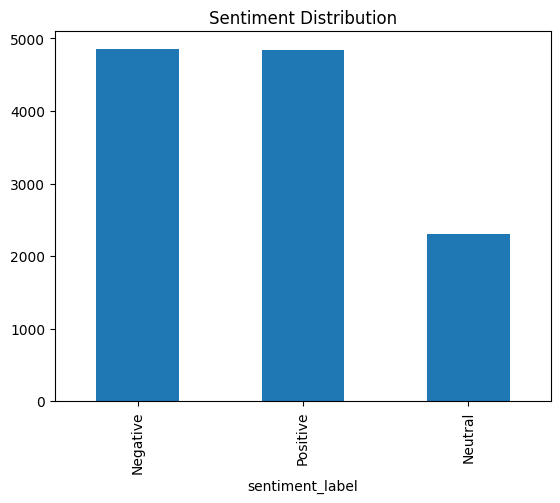

In [14]:
#Check sentiments

df["sentiment_label"].value_counts()

#Graph

df["sentiment_label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.show()

##Module 5: Virality Analysis



---



In [15]:
#Create Score

df["toxicity_score"] = (df["likes_count"] + 2 * df["comments_count"] + 3 * df["shares_count"])

#Top Viral Posts

df.sort_values(
    by="toxicity_score",
    ascending=False
).head(10)



,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
459,7v5a8zyj4gw5,2024-06-23 09:31:00,Sunday,YouTube,user_qbclaspk,"Seoul, South Korea",ru,How do I fix about Samsung's Neo QLED TV? @Bra...,"#Discount, #Promo","@BrandSupport, @StyleGuide",...,950,24553,0.32175,Samsung,Neo QLED TV,BlackFriday,Pre-Launch,-0.7982,-0.1077,95.0
11947,ycjj5zzt7mvx,2025-02-19 05:57:35,Wednesday,Instagram,user_3w27ggio,"London, UK",ja,Coca-Cola HolidaySpecial is fantastic! Can't w...,"#TrendAlert, #Reviews, #Food",@CustomerService,...,991,74605,0.10579,Coca-Cola,Coke Zero,BackToSchool,Post-Launch,0.8372,0.0011,91.1
3075,wo7py9aljg3t,2025-04-28 20:25:50,Monday,Reddit,user_50qjuqdj,"São Paulo, Brazil",pt,Attended the Nike LaunchWave event yesterday. ...,"#NewRelease, #Affordable, #ProductLaunch",NaN,...,948,65545,0.11889,Nike,Epic React,NextGeneration,Pre-Launch,0.0610,0.3124,60.7
8925,3dh1ecglz4bd,2024-06-04 16:23:20,Tuesday,Reddit,user_np966onv,"Berlin, Germany",es,Has anyone else experienced connectivity issue...,"#Tech, #Innovation",@InfluencerName,...,983,89017,0.08781,Toyota,Tundra,CyberMonday,Launch,0.3292,0.3187,-65.1
6899,5kvuyvf38nqx,2024-06-09 14:59:35,Sunday,YouTube,user_n6p8x5xw,"Vancouver, Canada",pt,Just tried the Sprite from Coca-Cola. Worth ev...,"#MustHave, #BestValue","@TechHelp, @ReviewSite",...,861,19062,0.40683,Coca-Cola,Sprite,ReferralBonus,Pre-Launch,-0.2511,-0.3105,-56.6
141,a1kiwl618kzy,2025-04-09 05:32:49,Wednesday,Facebook,user_810nlx6f,"Milan, Italy",ja,Just tried the Zoom Pegasus from Nike. Wouldn'...,"#Sale, #Trending","@BrandSupport, @TechHelp",...,920,97516,0.07878,Nike,Zoom Pegasus,ValentinesDeals,Pre-Launch,-0.2622,-0.1514,19.1
1770,gmoeib832zbs,2025-01-24 10:39:09,Friday,Facebook,user_kk1decwg,"Shanghai, China",hi,Should I upgrade about Apple's iPhone 15? @Tec...,#Fashion,"@TechHelp, @CelebrityName",...,982,39541,0.19635,Apple,iPhone 15,ValentinesDeals,Pre-Launch,0.8004,-0.1180,-71.3
9015,5n161ir5hhhr,2025-01-26 00:44:23,Sunday,YouTube,user_95cogcij,"Toronto, Canada",en,Just unboxed my new NMD from Adidas. Not worth...,"#Premium, #Quality, #Eco","@BrandSupport, @ProductTeam",...,878,70275,0.10828,Adidas,NMD,LoyaltyRewards,Post-Launch,0.7618,0.1426,56.0
7362,fp89q1ickn9w,2025-03-15 18:19:33,Saturday,Twitter,user_xua7xwfu,"Lagos, Nigeria",de,Comparing Toyota Prius to the competition. Had...,#Deal,@CelebrityName,...,955,34902,0.21855,Toyota,Prius,BackToSchool,Launch,0.1239,0.2327,-45.2
4093,tdgjjylpua20,2024-06-02 14:39:08,Sunday,YouTube,user_j2o4po42,"Paris, France",zh,Comparing Adidas Samba to the competition. Had...,"#Limited, #Food","@MarketingTeam, @RetailSupport",...,812,74939,0.10305,Adidas,Samba,SpringBlast2025,Launch,-0.6956,0.4620,81.7


##Module 6: Machine Learning

######Predict Engagement Rate

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [17]:
#feature
X = df[
    [
        "likes_count",
        "comments_count",
        "shares_count"
    ]
]


In [18]:
#target
y = df["engagement_rate"]

In [19]:
# Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model

model = LinearRegression()

model.fit(X_train, y_train)

# Accuracy

print(model.score(X_test, y_test))

0.010784111951206654


In [20]:
df.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,NaN,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",NaN,...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport",...,743,6696,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName",...,703,47315,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["likes_count","comments_count","shares_count"]]
y = df["engagement_rate"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [22]:
score = model.score(X_test, y_test)

print("R2 Score:", score)

R2 Score: 0.010784111951206654


In [23]:
predictions = model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": predictions[:10]
})

results

,Actual,Predicted
0,0.10062,0.311700
1,0.12714,0.211163
2,4.39035,0.307688
3,0.04179,0.189195
4,0.04875,0.262455
5,1.21707,0.179205
6,0.04438,0.237280
7,0.02727,0.179416
8,0.04255,0.208862
9,0.16173,0.156530


In [24]:
print(df.columns.tolist())

['post_id', 'timestamp', 'day_of_week', 'platform', 'user_id', 'location', 'language', 'text_content', 'hashtags', 'mentions', 'keywords', 'topic_category', 'sentiment_score', 'sentiment_label', 'emotion_type', 'toxicity_score', 'likes_count', 'shares_count', 'comments_count', 'impressions', 'engagement_rate', 'brand_name', 'product_name', 'campaign_name', 'campaign_phase', 'user_past_sentiment_avg', 'user_engagement_growth', 'buzz_change_rate']


In [25]:
predictions = model.predict(X_test)

print(predictions[:10])

[0.31169957 0.21116255 0.30768773 0.18919496 0.26245479 0.1792049
 0.2372797  0.17941631 0.20886242 0.15652968]
